In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Import et lecture du fichier billets.csv

billets = pd.read_csv("/content/drive/MyDrive/Projet_Detection_Billet/billets.csv", sep=";")
billets.head()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [4]:
#Taille du fichier
billets.shape

(1500, 7)

In [5]:
#Vérification des types de varibales
billets.dtypes

,0
is_genuine,bool
diagonal,float64
height_left,float64
height_right,float64
margin_low,float64
margin_up,float64
length,float64


Nous avons 2 types de variables :

*   1 Variable qualitative : is_genuine (varibale booleene)
*   6 Variables quantitatives : diagonal,height_left, height_right, margin_low, margin_up, length

● length : la longueur du billet (en mm) ;

● height_left : la hauteur du billet (mesurée sur le côté gauche, en
mm) ;

● height_right : la hauteur du billet (mesurée sur le côté droit, en mm) ;

● margin_up : la marge entre le bord supérieur du billet et l'image de
celui-ci (en mm) ;

● margin_low : la marge entre le bord inférieur du billet et l'image de celui-ci (en mm) ;

● diagonal : la diagonale du billet (en mm).



***Recherhce de doublons***

In [6]:
#Vérification des Doublons pour toutes les colonnes
print('Nombre de doublons en considérant toutes les colonnes ' + str(billets.duplicated().sum()))

Nombre de doublons en considérant toutes les colonnes 0


In [7]:
#Vérification des Doublons pour les variables quantitatives

cols_num = billets.select_dtypes(include='number').columns
doublons_num = billets.duplicated(subset=cols_num)
print('Nombre de doublons en considérant les variables quantitatives ' + str(doublons_num.sum()))


Nombre de doublons en considérant les variables quantitatives 0


Pas de doublons.

***Visualisation du taux des faux et des vrais billets***

In [8]:
#La varibale qualitative : is_genuine -->  Le nombre de faux et vrais billets

billets["is_genuine"].value_counts()

,count
is_genuine,
True,1000
False,500


Text(0.5, 1.0, 'Taux des vrais et faux billets')

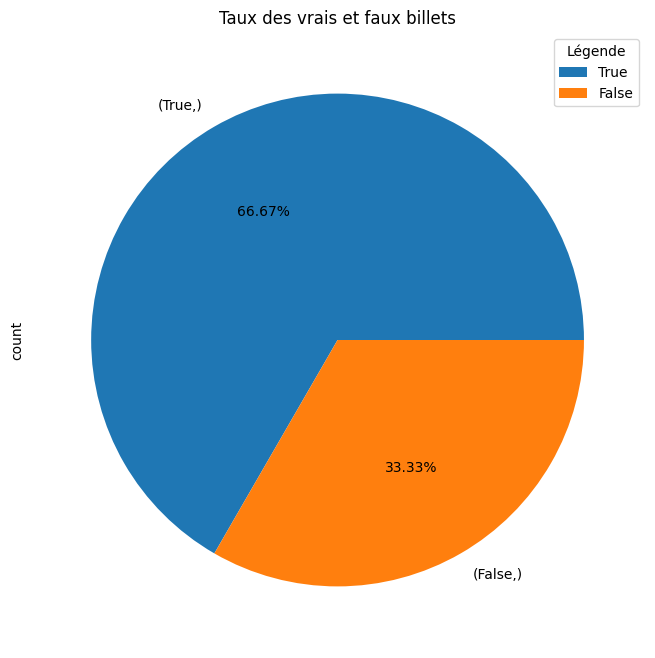

In [9]:
# afficher les taux de faux billets et des vrais billets
plt.figure(figsize=(15, 8))
billets[['is_genuine']].value_counts().plot.pie(autopct = lambda x: str(round(x, 2)) + '%')
labels = ['True', 'False']
plt.legend(labels, title='Légende', loc='upper right')
plt.title('Taux des vrais et faux billets')

***Recherche des outliers***

In [10]:
#Verification s'il y a des outliers
billets.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


Pas de données abbérantes à première vue juste des données manquantes au niveau de margin_low (count = 1463 or toutes les autres varibales 1500) à vérifier.

Nous allons vérifier l'existance des données abérantes par l'analyse de boxplot

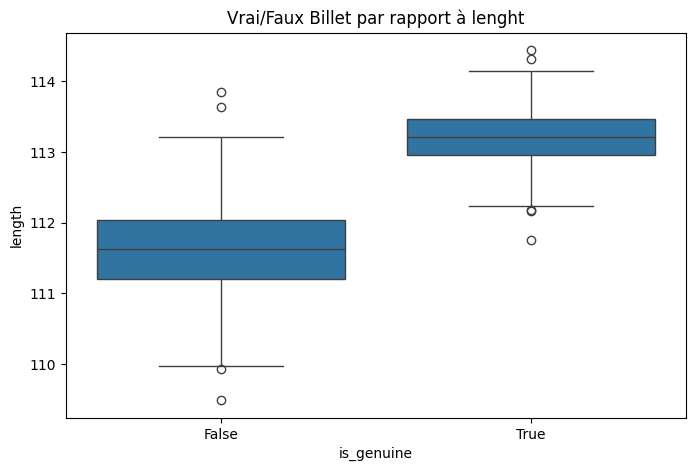

In [11]:
#Boxplot

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(
    x=billets['is_genuine'],
    y=billets['length']
)


plt.title("Vrai/Faux Billet par rapport à lenght")
plt.xlabel("is_genuine")
plt.ylabel("length")

#Géneration de png
plt.savefig("/content/drive/MyDrive/Projet_Detection_Billet/Boxplot_lenght.png", dpi=300, bbox_inches="tight")
plt.show()


- Les billets authentiques sont plus long (lenght) que les faux
billets: la médiane des vrais billets est plus élevée que la médiane des faux billets.
- La distribution des faux billets est plus étalées par rapport à celle des vrais billets.
--> La longueur des faux billets présente une dispersion plus élevée que celle des billets authentiques, indiquant une plus grande variabilité dans leur fabrication.
- Nous pouvons dire à partir de la distribution des vrais billets qu'il y a un standard de normalisation de longeur des vrais billets.

- Il y a des outliers sur les 2 classes (False et True).

- Les boites se chevauchent partiellement : entre la valeur inférieur du boxplot des vrais billets et  la valeur supérieure du boxplot des faux billets --> Nous allons utiliser la règle de Tukey pour les calculer.

- Echelle utilisé : 1 mm


In [12]:
#Calcul de la médiane pour les boxplots
billets.groupby("is_genuine")["length"].median()

,length
is_genuine,
False,111.630
True,113.205


In [13]:
#Recheche de la partie du chevauchement des 2 boxplots
vrais = billets[billets["is_genuine"]]
faux  = billets[~billets["is_genuine"]]

Les bornes inférieure et supérieure du boxplot ont été calculées à partir de la règle de Tukey, définie comme Q1 − 1,5×IQR et Q3 + 1,5×IQR. Toute observation située en dehors de cet intervalle est considérée comme une valeur aberrante (outliers).

In [14]:
#Règle de Tukey pour les vrais billets

Q1 = vrais["length"].quantile(0.25)
Q3 = vrais["length"].quantile(0.75)

IQR = Q3 - Q1

borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

print("la borne supérieure du boxplot des vrais billets est ", borne_sup, "et la borne inférieure du boxplot des vrais billets est",borne_inf  )

la borne supérieure du boxplot des vrais billets est  114.22499999999998 et la borne inférieure du boxplot des vrais billets est 112.18500000000002


In [15]:
billets.loc[billets['length'] == 112.18]

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
591,True,171.67,103.81,103.76,4.59,3.30,112.18
1095,False,171.83,104.11,103.92,5.63,3.21,112.18
1236,False,172.57,104.13,104.19,5.10,3.45,112.18
1307,False,171.68,104.24,104.00,4.49,3.24,112.18
1317,False,171.99,104.28,104.32,4.71,3.45,112.18


In [16]:
#Règle de Tukey pour les faux billets

Q1 = faux["length"].quantile(0.25)
Q3 = faux["length"].quantile(0.75)

IQR = Q3 - Q1

borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

print("la borne supérieure du boxplot des faux billets est ", borne_sup, "et la borne inférieure du boxplot des faux billets est",borne_inf  )

la borne supérieure du boxplot des faux billets est  113.275 et la borne inférieure du boxplot des faux billets est 109.95500000000001


In [17]:
faux.loc[faux['length'] == 113.27]

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length


In [18]:
billets.loc[billets['length'] == 113.27]

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
93,True,172.05,103.75,103.98,4.10,3.12,113.27
104,True,171.96,103.95,103.81,4.23,3.09,113.27
197,True,171.45,103.66,103.80,NaN,3.62,113.27
298,True,172.43,103.83,104.13,3.72,2.81,113.27
337,True,171.59,103.80,103.95,4.09,2.89,113.27
388,True,172.42,104.07,103.73,4.23,3.11,113.27
488,True,172.19,104.07,104.02,4.19,3.37,113.27
603,True,172.08,104.03,103.42,3.79,2.77,113.27
675,True,171.60,103.85,103.91,NaN,2.56,113.27
712,True,172.09,103.68,103.99,3.74,3.28,113.27


la borne sup du boxplot des faux négatifs indique la valeur 113.27 et on cherchant les valeurs concernées on ne trouve que des vrais billets.
--> Les bornes du boxplot ont été calculées séparément pour chaque classe.
Nous avons trouvé que certaines valeurs considérées comme atypiques pour les faux billets correspondent à des valeurs courantes chez les billets authentiques.

***--> Les bornes du boxplots décrivent la dispersion interne d’un groupe et ne constituent pas des seuils de discrimination entre classes.***

In [19]:
billets.loc[billets['length'] == 113.21]

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
446,True,172.51,104.53,103.50,4.51,3.07,113.21
462,True,171.48,103.95,103.93,4.52,2.91,113.21
485,True,171.83,104.29,103.58,4.00,3.32,113.21
535,True,171.68,104.18,103.89,4.40,3.33,113.21
542,True,171.64,103.95,103.45,3.98,3.11,113.21
682,True,172.24,104.51,103.97,4.18,3.22,113.21
745,True,172.16,103.92,103.76,4.35,2.84,113.21
885,True,171.71,104.14,103.99,4.49,3.15,113.21
932,True,171.77,104.27,103.94,4.34,2.87,113.21
998,True,171.44,103.96,103.92,3.68,2.89,113.21


Un peu de Chevauchement : les billets ont une longeur (lenght) entre [112.18, 113.21].
--> La varibale lenght est très importante et elle est discriminante et utile pour différencier les 2 classes.

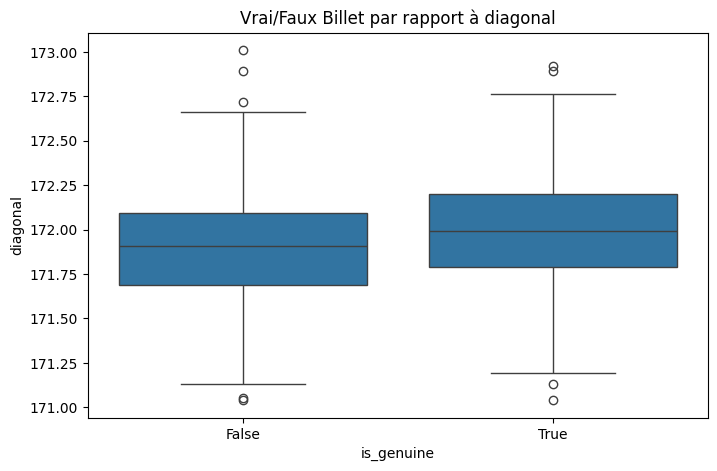

In [20]:
#Boxplot

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(
    x=billets['is_genuine'],
    y=billets['diagonal']
)


plt.title("Vrai/Faux Billet par rapport à diagonal")
plt.xlabel("is_genuine")
plt.ylabel("diagonal")

#Géneration de png
plt.savefig("/content/drive/MyDrive/Projet_Detection_Billet/Boxplot_diagonal.png", dpi=300, bbox_inches="tight")

plt.show()

- Nous voyons bien que les 2 boxplots ont à peu près des valeurs similaires et il y a des outilers:
- La distribution (Les médianes, la disperssion) sont à peu près similaires dans les 2 boxplots. --> Il ya un fort chevauchement.

--> La variable diagonal  ne permet pas de différencier visuellement les deux classes (False et True) donc besoin d'étudier les autres varibales.

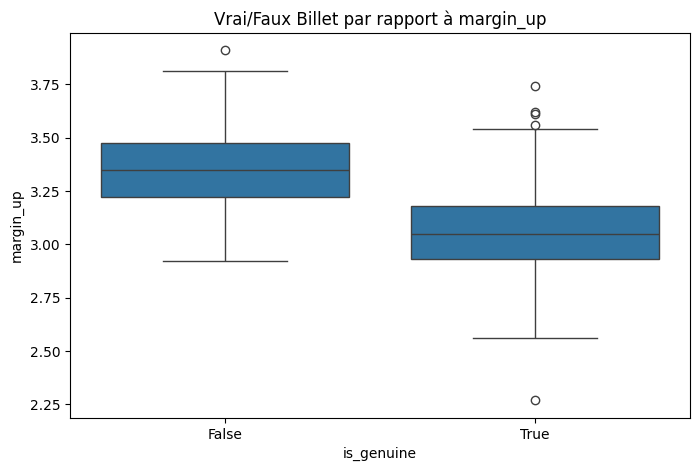

In [21]:
#Boxplot

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(
    x=billets['is_genuine'],
    y=billets['margin_up']
)


plt.title("Vrai/Faux Billet par rapport à margin_up")
plt.xlabel("is_genuine")
plt.ylabel("margin_up")

#Géneration de png
plt.savefig("/content/drive/MyDrive/Projet_Detection_Billet/Boxplot_margin_up.png", dpi=300, bbox_inches="tight")
plt.show()

* La varibale margin_up est plus élevée dans les faux billets par rapport aux vrais billets.
* Il y a des outliers.

* Les deux distributions ont une forme similaire mais sont décalées
l’une par rapport à l’autre (les médianes sont décalées)
* Il y a un moyen chevauchement.

--> Cela montre que la variable est  utile pour différencier les deux classes.

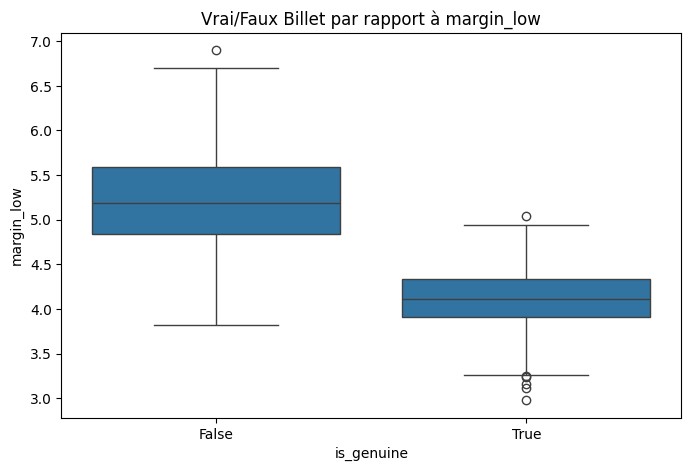

In [22]:
#Boxplot

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(
    x=billets['is_genuine'],
    y=billets['margin_low']
)


plt.title("Vrai/Faux Billet par rapport à margin_low")
plt.xlabel("is_genuine")
plt.ylabel("margin_low")

#Géneration de png
plt.savefig("/content/drive/MyDrive/Projet_Detection_Billet/Boxplot_margin_low.png", dpi=300, bbox_inches="tight")

plt.show()

La margin_low est plus importante dans les faux billets que dans les vrais billets (médiane bien décalée).
La distribution des faux billets est plus étalées par rapport à celle des vrais billets. --> La margin_low des faux billets présente une dispersion plus élevée et des moustaches plus longues que celle des billets authentiques, indiquant une plus grande variabilité dans leur fabrication.
--> --> La varibale margin_low est très importante et elle est discriminante et utile pour différencier les 2 classes.

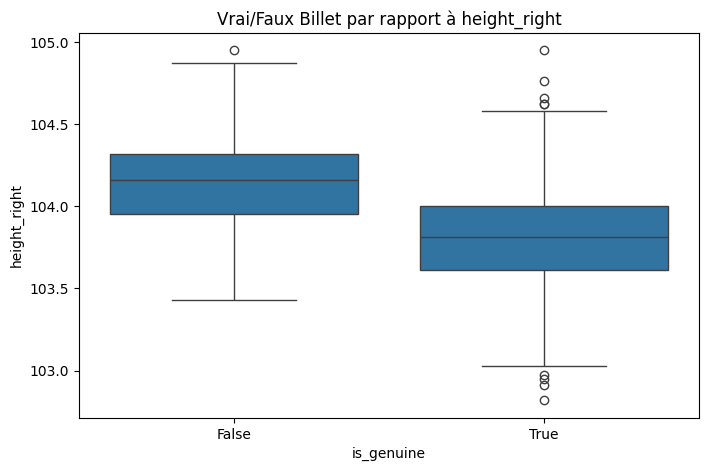

In [23]:
#Boxplot

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(
    x=billets['is_genuine'],
    y=billets['height_right']
)


plt.title("Vrai/Faux Billet par rapport à height_right")
plt.xlabel("is_genuine")
plt.ylabel("height_right")

#Géneration de png
plt.savefig("/content/drive/MyDrive/Projet_Detection_Billet/Boxplot_height_right.png", dpi=300, bbox_inches="tight")
plt.show()

* La varibale height_right est plus élevée dans les faux billets par rapport aux vrais billets.
* Il y a des outliers.

* Les deux distributions ont une forme similaire mais sont décalées
l’une par rapport à l’autre (les médianes sont décalées)
* Il y a un moyen chevauchement.

--> Cela montre que la variable est  utile pour différencier les deux classes.

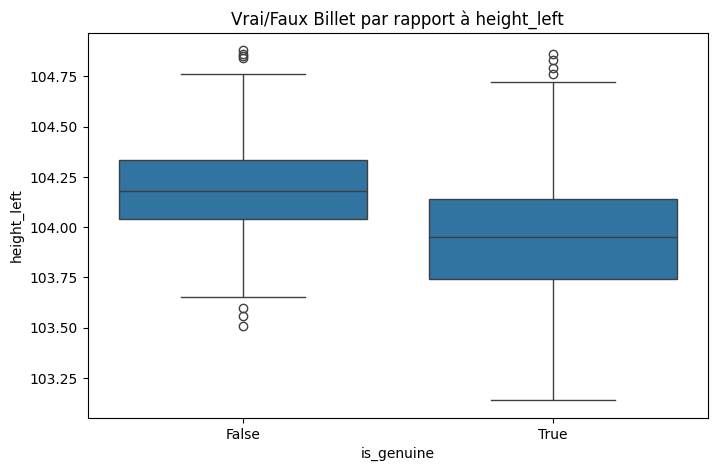

In [24]:
#Boxplot

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(
    x=billets['is_genuine'],
    y=billets['height_left']
)


plt.title("Vrai/Faux Billet par rapport à height_left")
plt.xlabel("is_genuine")
plt.ylabel("height_left")

#Géneration de png
plt.savefig("/content/drive/MyDrive/Projet_Detection_Billet/Boxplot_height_left.png", dpi=300, bbox_inches="tight")

plt.show()

* La varibale height_left est plus élevée (médiane) dans les faux billets par rapport aux vrais billets.
* Il y a des outliers.
* La distribution des vrais billets est plus étalées par rapport à celle des faux billets.

--> La varibale height_left des vrais billets présente une dispersion plus élevée et des moustaches plus longues que celle des billets falsifiés, indiquant une plus grande variabilité dans leur fabrication.

--> Chevauchement de moyen à fort
--> Cela montre que la variable est  utile pour différencier les deux classes.

**Remarques: Le boxplot donne une vision synthétique de la distribution des données : on observe la médiane, la dispersion et la présence éventuelle d’outliers.**

*   chevauchement faible: lenght + margin_low
*   chevauchement moyen : margin_up + hight_right + hight_left
*   chevauchement fort : Diagonal

--> Le chevauchement des boxplots permet d’évaluer la capacité des variables à distinguer les deux classes (True et False).

--> Il existe des outliers : Un outlier statistique n’est pas nécessairement une anomalie métier.

--> Les boxplots ont mis en évidence des valeurs extrêmes au sens statistique. Cependant, après analyse, ces observations ne correspondent pas à des erreurs de mesure ni à des incohérences métier. Elles restent physiquement plausibles et reflètent la variabilité naturelle des caractéristiques des billets. Les supprimer ou les remplasser par des NaN aurait risqué de perdre de l’information utile et de biaiser l’apprentissage des modèles. C’est pourquoi elles ont été conservées.

| Dimensions | Echelle sur Boxplot(mm) | Borne min| Borne Sup | Variations |
| :--- | :--- | :--- | :--- | :--- |
| lenght |1 |109.49 |114.44 | 5.4|
| diagonal | 0.25|171.04 |173.01 |1.97 |
| margin_up |0.25 |2.27 |3.91|1.64 |
| margin_low |0.5 |2.98 |6.90 |3.92 |
| hight_left |0.25 |103.14 |104.88 | 1.74|
| hight_right |0.5 |102.82 |104.95 |2.13 |

***Vérification des valeurs manquantes***

In [25]:
#vérification des valeurs manquantes
print(billets.isnull().sum())

is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64



*   37 valeurs manquantes dans la varibale margin_low



In [26]:
#Détail des valeurs manquantes pour le margin_low
billets.loc[billets['margin_low'].isnull(),:]

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
72,True,171.94,103.89,103.45,NaN,3.25,112.79
99,True,171.93,104.07,104.18,NaN,3.14,113.08
151,True,172.07,103.80,104.38,NaN,3.02,112.93
197,True,171.45,103.66,103.80,NaN,3.62,113.27
241,True,171.83,104.14,104.06,NaN,3.02,112.36
251,True,171.80,103.26,102.82,NaN,2.95,113.22
284,True,171.92,103.83,103.76,NaN,3.23,113.29
334,True,171.85,103.70,103.96,NaN,3.00,113.36
410,True,172.56,103.72,103.51,NaN,3.12,112.95
413,True,172.30,103.66,103.50,NaN,3.16,112.95


Notre but est de vérifier si les billets sont vrais ou fausses.

Les billets ont des dimensions et nous avons margin_low la variable qui présente le plus de valeurs manquantes.

Nous pouvons l'imputer par régression linéaire mais avant cela nous devons vérifier la linéarité entre la varibale à imputer (margin_low) avec les autres varibales explicatives.

***Analyse bivarié entre les variables quantitatives***

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

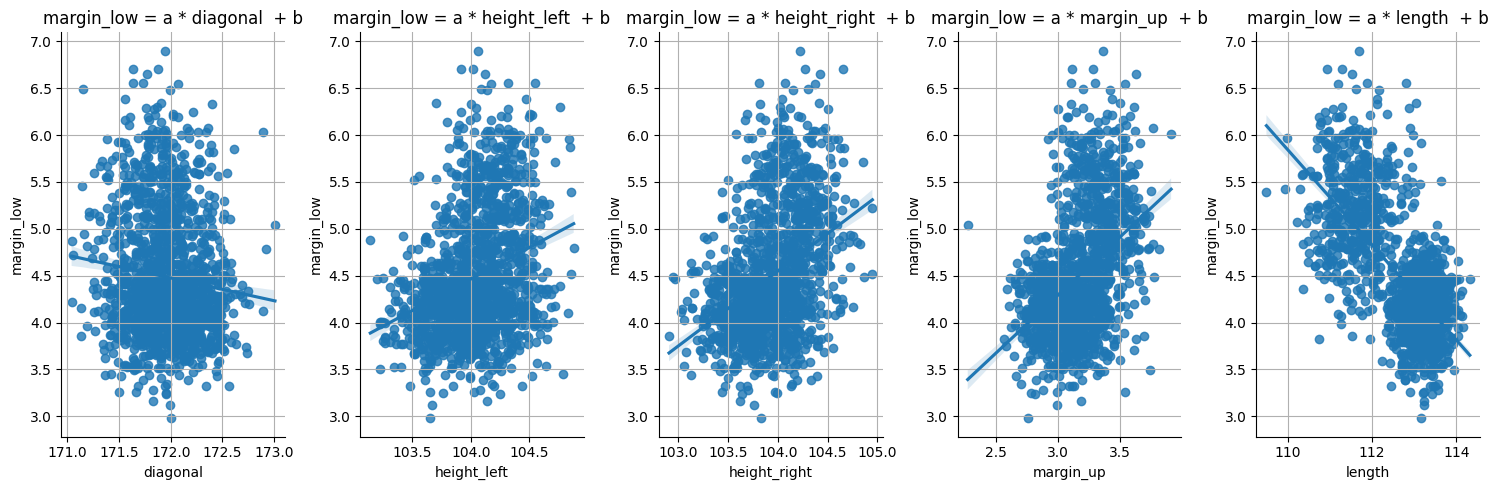

In [28]:
# Vérification de la linéarité entre les varibles explicatives avec margin_low (varibale à imputer) par des schémas

fig, ax = plt.subplots(1,5, figsize = (15,5))

# préparer les données sans valeurs manquantes
df = billets[billets["margin_low"].notna()]

plt.subplot(1,5,1)
sns.regplot(x = df[['diagonal']],y  =  df.margin_low)
plt.ylabel('margin_low')
plt.xlabel('diagonal')
plt.title('margin_low = a * diagonal  + b')
plt.grid()
sns.despine()

plt.subplot(1,5,2)
sns.regplot(x = df[['height_left']],y  =  df.margin_low)
plt.ylabel('margin_low')
plt.xlabel('height_left')
plt.title('margin_low = a * height_left  + b')
plt.grid()
sns.despine()

plt.subplot(1,5,3)
sns.regplot(x = df[['height_right']],y  =  df.margin_low)
plt.ylabel('margin_low')
plt.xlabel('height_right')
plt.title('margin_low = a * height_right  + b')
plt.grid()
sns.despine()

plt.subplot(1,5,4)
sns.regplot(x = df[['margin_up']],y  =  df.margin_low)
plt.ylabel('margin_low')
plt.xlabel('margin_up')
plt.title('margin_low = a * margin_up  + b')
plt.grid()
sns.despine()

plt.subplot(1,5,5)
sns.regplot(x = df[['length']],y  =  df.margin_low)
plt.ylabel('margin_low')
plt.xlabel('length')
plt.title('margin_low = a * length  + b')
plt.grid()
sns.despine()


plt.tight_layout()
plt.show()

- margin_low ~ diagonal -- > Nuage très dispersé (pente négative)
--> Relation faible, mais approximativement linéaire.

- margin_low ~ height_left  & margin_low ~ height_left --> Nuage dispersé (pente positive)
--> Relation faible, mais approximativement linéaire.

- margin_low ~ margin_up --> Nuage bien orienté
--> Relation linéaire

- margin_low ~ lenght --> Nuage bien orienté
--> Relation linéaire

- La zone bleu pâle montre :
    - lenght est plus prédictive que les autres variables.
    - diagonal est la varible la moins prédictive.

--> Les relations entre la variable à imputer (margin_low) et les autres variables explicatives montrent des tendances approximativement linéaires.

--> Etudier la possibilité d'une imputation par régression linéaire.


***Etudier la possibilité d'une imputation par Régression linéaire***

In [29]:
# Séparation des données observées et données manquantes pour la varibale cible à imputer
billets_obs = billets[billets["margin_low"].notna()]
billets_miss = billets[billets["margin_low"].isna()]

In [30]:
# Définir X et Y (modèle d’imputation)

X_cols = ["diagonal", "height_left", "height_right", "margin_up", "length"]

X_train = billets_obs[X_cols]
y_train = billets_obs["margin_low"]


In [31]:
# Entraîner la régression linéaire

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

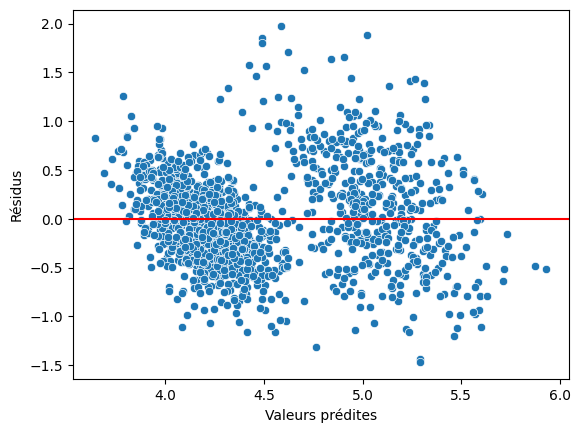

In [32]:
# Vérification des résidus
#C’est l’étape qui permet de vérifier si :le modèle est cohérent avec les données et ses hypothèses.

#Pour une régression linéaire, on cherche des résidus :centrés autour de 0 + aléatoires + de variance constante + sans structure



y_pred = model.predict(X_train)
residus = y_train - y_pred

sns.scatterplot(x=y_pred, y=residus)
plt.axhline(0, color="red")
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.show()

- Les résidus ne sont ni homogènes ni aléatoires : ils se regroupent en deux amas et leur dispersion varie selon les valeurs prédites, ce qui montre que la régression linéaire ne capture pas correctement la structure des données.

- La structure bimoale (2 groupes) et l'hétéroscédasticité observées (indiquant une variance non constante des erreurs) démontrent que la relation entre les variables est conditionnée par la nature du billet (Vrai/Faux).

--> Imputer via ce modèle introduirait un biais systématique, affaiblissant la séparation entre les classes.

--> Ces éléments montrent que les hypothèses de la régression linéaire ne sont pas respectées (linéarité + homoscedasticité), rendant le modèle inadapté pour une imputation fiable.

--> **Une imputation n’est pertinente que si les hypothèses du modèle sont respectées**.

***Les résidus présentent une structure marquée et une variance non constante, ce qui invalide la régression linéaire. Pour éviter une imputation biaisée, nous avons privilégié une imputation par KNN, plus robuste aux relations non linéaires et à la présence de sous-groupes.***

In [33]:
#Remplissage des valeurs manquantes : imputation par KNN
#L’imputation par KNN (K-Nearest Neighbors) est une méthode pour remplir les valeurs manquantes
#dans un jeu de données en utilisant les données les plus proches.
#Pour les valeurs manquantes de margin_low , on regarde les lignes qui lui ressemblent le plus
#et on utilise leurs valeurs pour la remplacer.

#Selectionner les colonnes float pour les préparer à l'imputation avec KNN
num_cols = billets.select_dtypes(include=['float64']).columns
df_num = billets[num_cols]
df_num

,diagonal,height_left,height_right,margin_low,margin_up,length
0,171.81,104.86,104.95,4.52,2.89,112.83
1,171.46,103.36,103.66,3.77,2.99,113.09
2,172.69,104.48,103.50,4.40,2.94,113.16
3,171.36,103.91,103.94,3.62,3.01,113.51
4,171.73,104.28,103.46,4.04,3.48,112.54
...,...,...,...,...,...,...
1495,171.75,104.38,104.17,4.42,3.09,111.28
1496,172.19,104.63,104.44,5.27,3.37,110.97
1497,171.80,104.01,104.12,5.51,3.36,111.95
1498,172.06,104.28,104.06,5.17,3.46,112.25


Pourquoi KNN est plus adapté que la régression: Méthode non paramétrique

pas d’hypothèse de linéarité

pas d’hypothèse de variance constante

--> Cohérent avec les données observées.

***L’imputation par KNN consiste à remplacer une valeur manquante par une valeur calculée à partir des k observations les plus proches, en se basant sur la similarité entre les individus.***

In [34]:

from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

#Normalisation et Imputation
scaler = StandardScaler()

from sklearn.impute import SimpleImputer

#choix de la startégie : la moyenne
imputer_mean = SimpleImputer(strategy='mean')

df_num = imputer_mean.fit_transform(df_num)

#choix du K=5
#Ce choix offre un bon équilibre entre robustesse face au bruit et conservation de l’information locale lors de l’imputation.

imputer = KNNImputer(n_neighbors=5)

df_scaled = scaler.fit_transform(df_num)
df_imputed_scaled = imputer.fit_transform(df_scaled)
df_imputed = scaler.inverse_transform(df_imputed_scaled)

billets[num_cols] = df_imputed
billets.head()


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [35]:
billets.loc[72]

,72
is_genuine,True
diagonal,171.94
height_left,103.89
height_right,103.45
margin_low,4.485967
margin_up,3.25
length,112.79


In [36]:
#Arrondir la colonne à 2 chiffre après la virgule
billets[num_cols] = billets[num_cols].round(2)
billets.loc[99]

,99
is_genuine,True
diagonal,171.93
height_left,104.07
height_right,104.18
margin_low,4.49
margin_up,3.14
length,113.08


In [37]:
billets.loc[251]

,251
is_genuine,True
diagonal,171.8
height_left,103.26
height_right,102.82
margin_low,4.49
margin_up,2.95
length,113.22


In [38]:
billets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1500 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


In [39]:
billets.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.486067,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.655569,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.030000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.330000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.860000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


In [40]:
#préparation de l'export du dataframe en fichier CSV

billets.to_csv('/content/drive/MyDrive/Projet_Detection_Billet/billets_nettoye.csv')

***Exploration des tests statistiques***

***1 - Distribution des données avec le test de la normalité des données
(Test Shapiro)***

Etudier les distribution des variables afin de comprendre comment les données sont réparties.

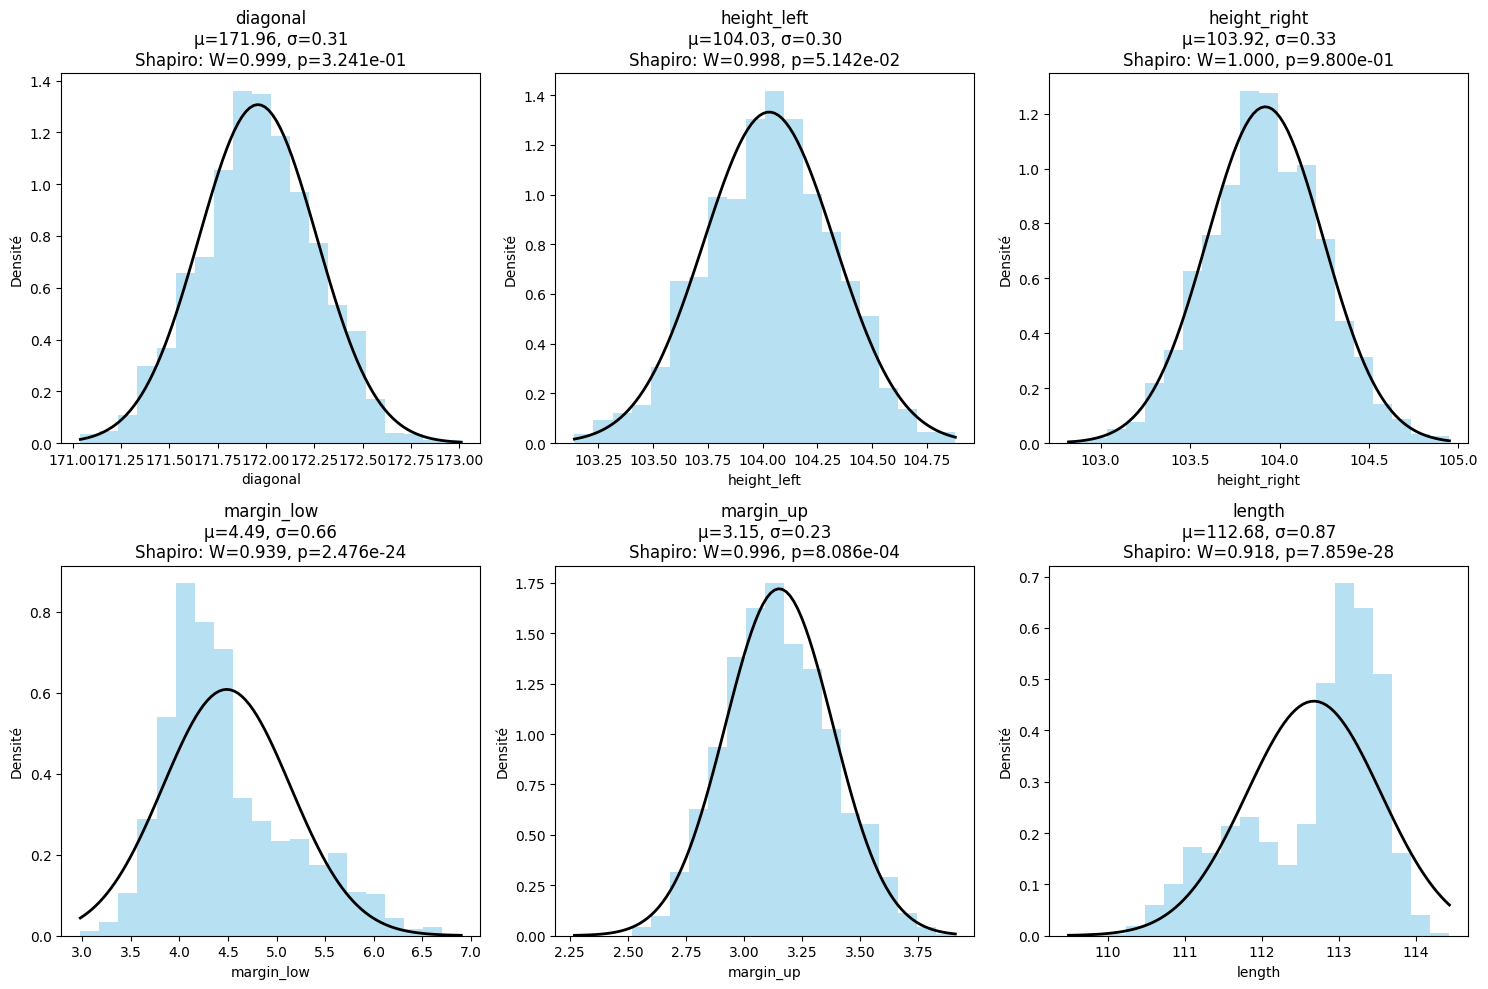

In [41]:


from scipy.stats import norm, shapiro

# Variables quantitatives
variables = billets.select_dtypes(include='number').columns

n_vars = len(variables)
n_cols = 3
n_rows = int(np.ceil(n_vars / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, var in enumerate(variables, 1):
    plt.subplot(n_rows, n_cols, i)

    data = billets[var].dropna()

    # Histogramme
    plt.hist(data, bins=20, density=True, alpha=0.6, color='skyblue')

    # Ajustement gaussien
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 100)
    plt.plot(x, norm.pdf(x, mu, sigma), 'k', linewidth=2)

    # Test de Shapiro-Wilk
    W, p_value = shapiro(data)

    plt.title(
        f"{var}\n"
        f"μ={mu:.2f}, σ={sigma:.2f}\n"
        f"Shapiro: W={W:.3f}, p={p_value:.3e}"
    )

    plt.xlabel(var)
    plt.ylabel("Densité")

plt.tight_layout()

 #Géneration de png
plt.savefig("/content/drive/MyDrive/Projet_Detection_Billet/Histogramme_Normalite.png", dpi=300, bbox_inches="tight")
plt.show()



Rappel :
H₀ : la variable suit une loi normale

p > 0.05 → normalité non rejetée

p ≤ 0.05 → normalité rejetée

W proche de 1 → forme proche d’une gaussienne

La majorité des variables ne suivent pas une loi normale stricte.

--> Le test de Shapiro-Wilk met en évidence que plusieurs variables ne
suivent pas une distribution normale (p < 0.05), notamment margin_low et length. Cette non-normalité justifie le recours à des méthodes non paramétriques et à des algorithmes robustes aux distributions non gaussiennes.

La non-normalité est dû au mélange de populations, c'est une information utile pour la classification.

***2- Etude de la corrélation des variables***

**Compte tenu de la non-normalité des variables, la corrélation de Spearman, plus robuste et adaptée aux relations non linéaires, est privilégiée à la corrélation de Pearson.**

In [42]:
# Sélection des variables quantitatives
df_num = billets.select_dtypes(include='number')

# Matrice de corrélation de Spearman
corr_spearman = df_num.corr(method='spearman')

corr_spearman


,diagonal,height_left,height_right,margin_low,margin_up,length
diagonal,1.000000,0.020055,-0.029748,-0.104802,-0.051097,0.096150
height_left,0.020055,1.000000,0.254122,0.292669,0.260195,-0.308700
height_right,-0.029748,0.254122,1.000000,0.391294,0.302853,-0.370605
margin_low,-0.104802,0.292669,0.391294,1.000000,0.416958,-0.583081
margin_up,-0.051097,0.260195,0.302853,0.416958,1.000000,-0.479832
length,0.096150,-0.308700,-0.370605,-0.583081,-0.479832,1.000000


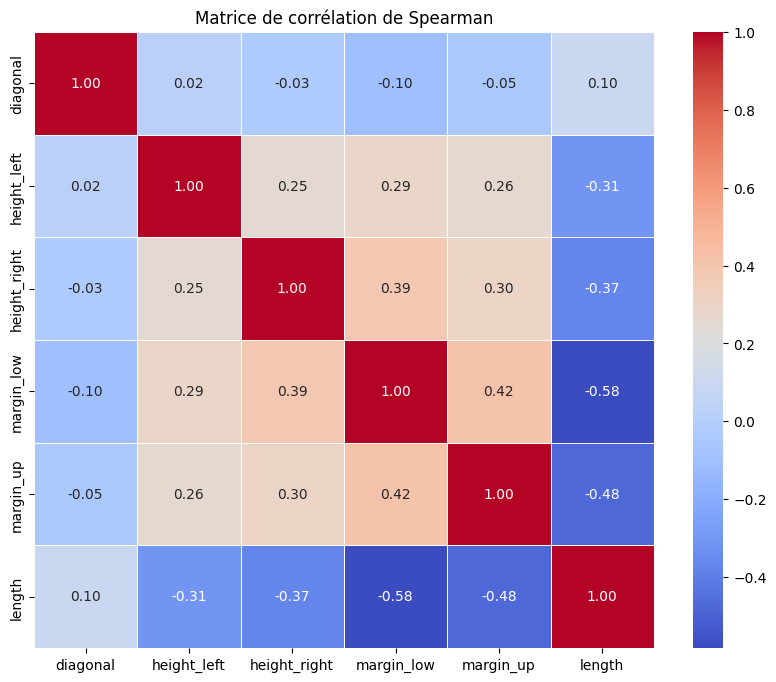

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_spearman,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title("Matrice de corrélation de Spearman")
#Géneration de png
plt.savefig("/content/drive/MyDrive/Projet_Detection_Billet/Matrice_Spearman.png", dpi=300, bbox_inches="tight")
plt.show()



*  lenght corrèle négativement avec  [margin_up, margin_low,height_left et height_right] et surtout avec margin_low

*  margin_up, margin_low,height_left et height_right corrèlent positivement entre eux

*  margin_up et margin_low corrèlent le plus positivement

* diagonal a une corrélation proche de 0 avec les autres varibales --> diagonal est indépendante

--> En se reposant sur l'étude des boxplots au-dessus et cette matrice de corrélation de Spearman, on peut conclure :


*   Un vrai billet a tendance a avoir plus en longueur: Un VRAI billet est un billet qui a le plus en lenght et le minimum en margin_low.

*   Un faux billet a tendance a avoir plus en margin_low, margin_up, height_left et height_right : Un FAUX billet est un billet qui a la valeur maximale [margin_up, margin_low,height_left et height_right], surtout en margin_low et la valeur minimale en lenght



***Réalisation de l'ACP afin de :***

*   Visualiser et explorer
*   Comprendre la structure globale
*   Détecter des groupes

In [44]:
# Standardisation des valeurs des variables : On centralise et on réduit les variables avant une ACP
# afin d’éliminer l’effet des unités de mesure et de garantir que
# chaque variable contribue de manière équitable à la construction des axes principaux.

# l'ACP repose des données quantitatives
df_billets = billets[['diagonal','height_left','height_right','margin_low','margin_up','length']]

#Centrer et réduire les données
#Scaling (Mise à l'échelle)
#unités différentes --> sinon une variable domine artificiellement l’ACP

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_billets)


In [45]:
##On espère avoir une moyenne à 0 et un écart type à 1
pd.DataFrame(X_scaled).describe().round(2).iloc[1:3:, : ]

,0,1,2,3,4,5
mean,-0.0,0.0,-0.0,-0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0


In [46]:
# Préparation de l'ACP
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.collections import LineCollection

In [47]:
# Chargement de seaborn

sns.set()

In [48]:
#ACP
#Une première ACP a été réalisée en conservant l’ensemble des composantes (6 variables) afin d’analyser la répartition de la variance
#et de déterminer le nombre optimal d’axes à retenir

n_components = 6

In [49]:
#Instanciation de l'ACP
pca = PCA(n_components=n_components)

In [50]:
#On l'entraine sur les données scalées :
pca.fit(X_scaled)

PCA(n_components=6)

In [51]:
#la variance captée par chaque nouvelle composante

pca.explained_variance_ratio_

array([0.42998111, 0.16964408, 0.13038875, 0.11829267, 0.09711478,
       0.05457861])

In [52]:
#Enregistrement dans une varibale
scree = (pca.explained_variance_ratio_*100).round(2)
scree

array([43.  , 16.96, 13.04, 11.83,  9.71,  5.46])

In [53]:
#Somme cumulée
scree_cum = scree.cumsum().round()
scree_cum

array([ 43.,  60.,  73.,  85.,  95., 100.])

In [54]:
#La liste de nos composantes

x_list = range(1, n_components+1)
list(x_list)

[1, 2, 3, 4, 5, 6]

Objectifs ACP :

*   Etudier la liaison entre les variables (les dimensions des billets)
*   Étudier la variabilité entre les individus (la nature des billets)



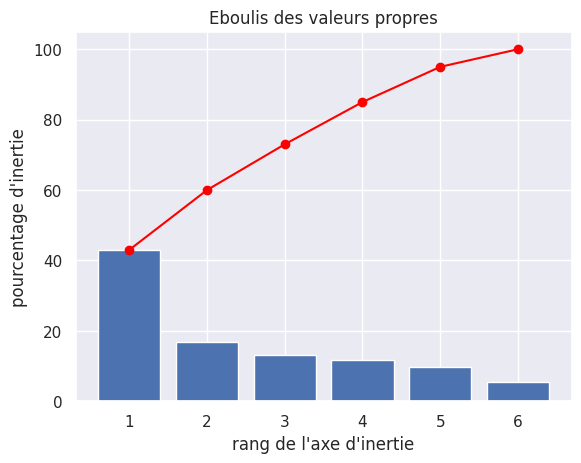

In [55]:
# Graphique : Eboulis des valeurs propres
plt.bar(x_list, scree)
plt.plot(x_list, scree_cum,c="red",marker='o')
plt.xlabel("rang de l'axe d'inertie")
plt.ylabel("pourcentage d'inertie")
plt.title("Eboulis des valeurs propres")
#Géneration de png
plt.savefig("/content/drive/MyDrive/Projet_Detection_Billet/Eboulis des valeurs propres.png", dpi=300, bbox_inches="tight")
plt.show(block=False)

# On a presque 60% de la variance  comprise dans les 2 premières composantes --> Partir sur 2 dimensions qui compose le premier plan factoriel (F1,F2)

In [56]:
#Components
pcs = pca.components_
pcs

array([[ 0.08536366, -0.33092771, -0.3947161 , -0.50375099, -0.44110217,
         0.52826406],
       [ 0.93977364,  0.31031597,  0.11023837, -0.07791043, -0.00321689,
         0.04792312],
       [-0.29265004,  0.88502608, -0.15484477, -0.12143879, -0.26484061,
         0.14906359],
       [-0.10235358, -0.05496969,  0.86969182, -0.09707177, -0.43580586,
         0.17546667],
       [-0.11570426,  0.08724668,  0.22706015, -0.58198332,  0.71303198,
         0.28341671],
       [ 0.00554757,  0.01691244,  0.0122325 ,  0.61423938,  0.19218903,
         0.76505354]])

In [57]:
#Version Pandas
pcs = pd.DataFrame(pcs)
pcs

,0,1,2,3,4,5
0,0.085364,-0.330928,-0.394716,-0.503751,-0.441102,0.528264
1,0.939774,0.310316,0.110238,-0.077910,-0.003217,0.047923
2,-0.292650,0.885026,-0.154845,-0.121439,-0.264841,0.149064
3,-0.102354,-0.054970,0.869692,-0.097072,-0.435806,0.175467
4,-0.115704,0.087247,0.227060,-0.581983,0.713032,0.283417
5,0.005548,0.016912,0.012232,0.614239,0.192189,0.765054


In [58]:
cols = ['diagonal','height_left',	'height_right','margin_low','margin_up','length']

In [59]:
pcs.columns = cols
pcs.index = [f"F{i}" for i in x_list]
pcs.round(2)

,diagonal,height_left,height_right,margin_low,margin_up,length
F1,0.09,-0.33,-0.39,-0.50,-0.44,0.53
F2,0.94,0.31,0.11,-0.08,-0.00,0.05
F3,-0.29,0.89,-0.15,-0.12,-0.26,0.15
F4,-0.10,-0.05,0.87,-0.10,-0.44,0.18
F5,-0.12,0.09,0.23,-0.58,0.71,0.28
F6,0.01,0.02,0.01,0.61,0.19,0.77


In [60]:
pcs.T

,F1,F2,F3,F4,F5,F6
diagonal,0.085364,0.939774,-0.292650,-0.102354,-0.115704,0.005548
height_left,-0.330928,0.310316,0.885026,-0.054970,0.087247,0.016912
height_right,-0.394716,0.110238,-0.154845,0.869692,0.227060,0.012232
margin_low,-0.503751,-0.077910,-0.121439,-0.097072,-0.581983,0.614239
margin_up,-0.441102,-0.003217,-0.264841,-0.435806,0.713032,0.192189
length,0.528264,0.047923,0.149064,0.175467,0.283417,0.765054


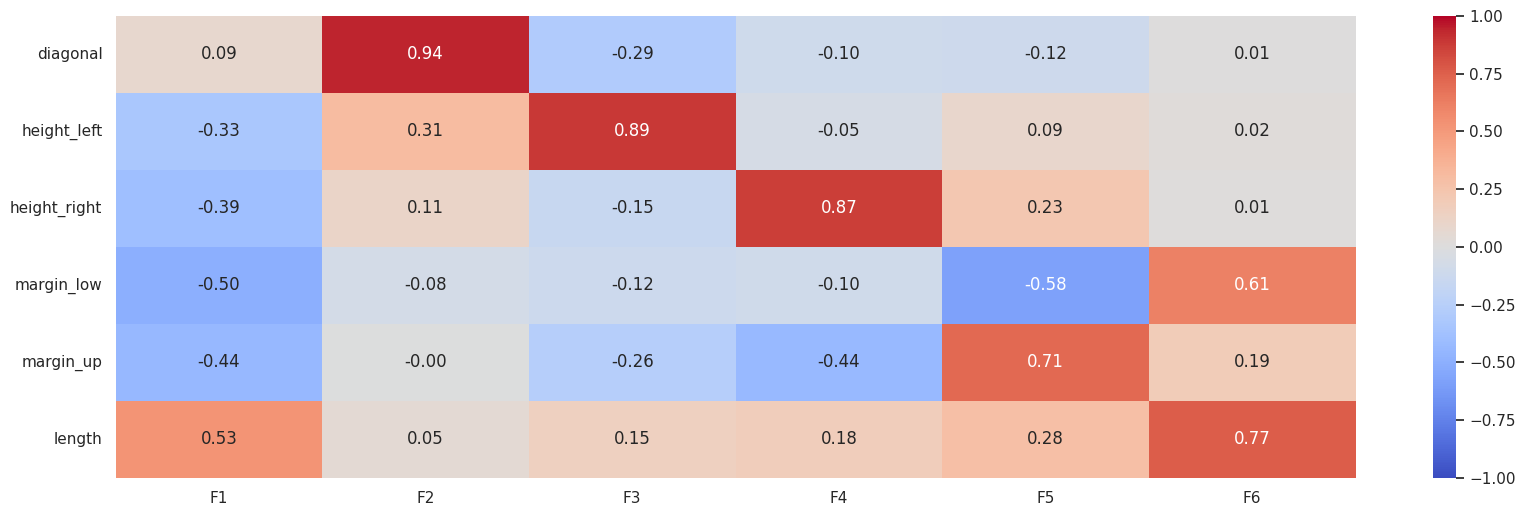

In [61]:
#Heatmap pour les différents dimensions

fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(pcs.T, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt="0.2f")
#Génération de png
fig.savefig("/content/drive/MyDrive/Projet_Detection_Billet/heatmap_Composantes_principale.png", dpi=300, bbox_inches="tight")  # image HD
plt.show()

In [62]:
F1 = pca.components_[0]
print(F1)

[ 0.08536366 -0.33092771 -0.3947161  -0.50375099 -0.44110217  0.52826406]


In [63]:
F2 = pca.components_[1]
print(F2)

[ 0.93977364  0.31031597  0.11023837 -0.07791043 -0.00321689  0.04792312]


In [64]:
#Fonction pour le cercle de corrélation

def correlation_graph(pca,
                      x_y,
                      features) :
    """Affiche le graphe des correlations

    Positional arguments :
    -----------------------------------
    pca : sklearn.decomposition.PCA : notre objet PCA qui a été fit
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2
    features : list ou tuple : la liste des features (ie des dimensions) à représenter
    """

    # Extrait x et y
    x,y=x_y

    # Taille de l'image (en inches)
    fig, ax = plt.subplots(figsize=(10, 9))

    # Pour chaque composante :
    for i in range(0, pca.components_.shape[1]):

        # Les flèches
        ax.arrow(0,0,
                pca.components_[x, i],
                pca.components_[y, i],
                head_width=0.07,
                head_length=0.07,
                width=0.02, )

        # Les labels
        plt.text(pca.components_[x, i] + 0.01,
                pca.components_[y, i] + 0.01,
                features[i])

    # Affichage des lignes horizontales et verticales
    plt.plot([-1, 1], [0, 0], color='grey', ls='--')
    plt.plot([0, 0], [-1, 1], color='grey', ls='--')

    # Nom des axes, avec le pourcentage d'inertie expliqué
    plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
    plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

    plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1))

    # Le cercle
    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale

    # Axes et display
    plt.axis('equal')
    #Géneration de png
    plt.savefig("/content/drive/MyDrive/Projet_Detection_Billet/cercle_correlationF1_F2.png", dpi=300, bbox_inches="tight")
    plt.show(block=False)



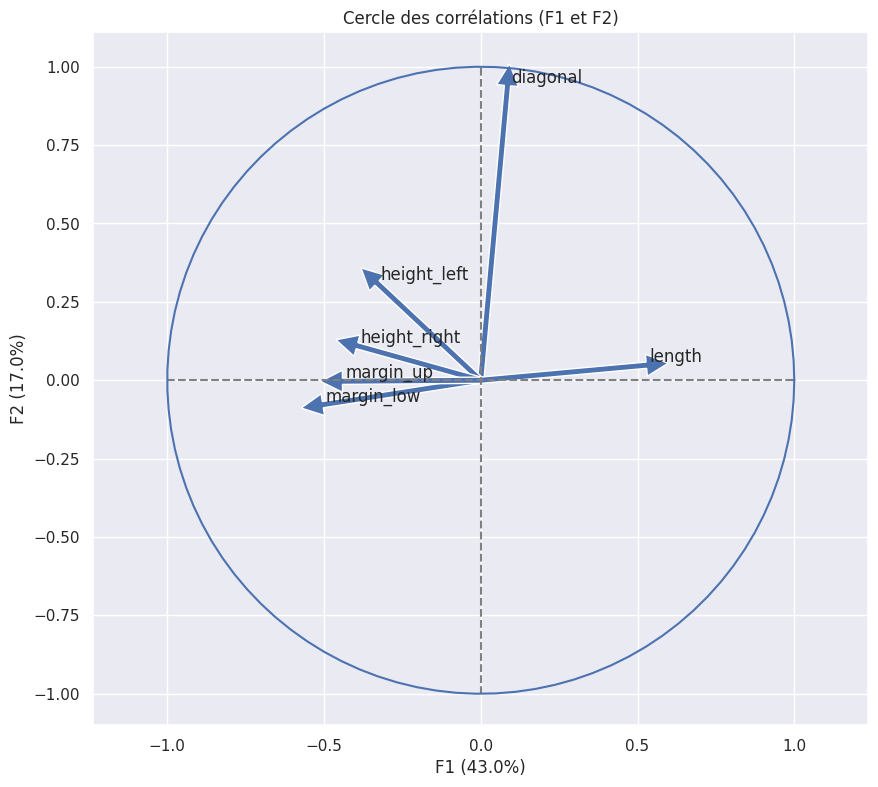

In [65]:
#F1 et F2
correlation_graph(pca, (0,1), cols)

- F1 porte 43% de l'information : length corrèle positivement avec F1 tandis que margin_up, margin_low, height_left et height_right corrèle négativement avec F1.
- lenght corrèle négativement avec margin_low, margin_up, height_left et height_right.
- lenght corrèle négativement avec margin_low corrèlation forte.
- margin_low corrèle positivement avec margin_up corrèlation forte.
- height_left corrèle positivement avec height_right corrèlation forte. --> margin_low, margin_up, height_left et height_right corrèlent ensemble positivement.


--> F1 : les dimensions extérieurs des billets: Quand la longueur d'un billet augumente, les autres varibales de l'extérieurs du billet diminuent et vis versa.

--> F2 porte 17% : cet axe est porté principalement par la variable diagonale, une dimension intérieure du billet.

In [66]:
#Projection des dimensions
#Calcul des coordonnées de nos individus dans le nouvel espace :
#Calcul des scores factoriles
X_proj = pca.transform(X_scaled)
X_proj[:5]
scores= X_proj

In [67]:
#ACP avec 2 dimensions (1 plans factoriel)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [68]:
df_pca = pd.DataFrame(
    X_pca,
    columns=['F1', 'F2']
)

In [69]:
df_pca['is_genuine'] = billets['is_genuine'].values

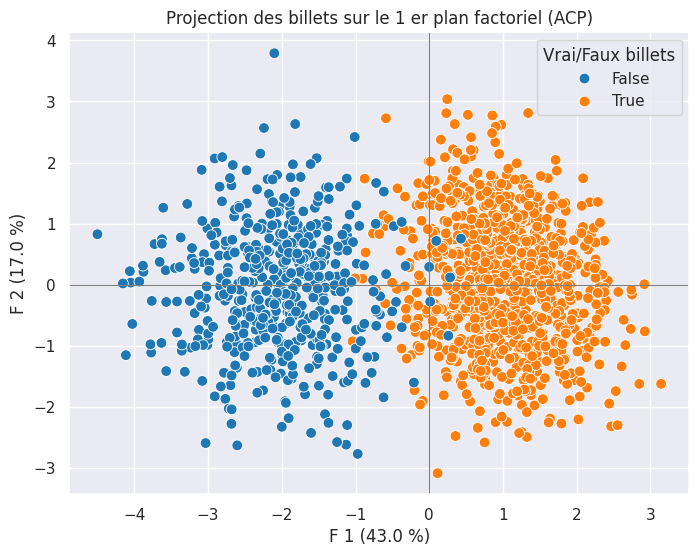

In [70]:
#Projection des billets sur F1 et F2

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_pca,
    x='F1',
    y='F2',
    hue='is_genuine',
    palette='tab10',
    s=60
)

plt.axhline(0, color='grey', linewidth=0.8)
plt.axvline(0, color='grey', linewidth=0.8)

plt.title("Projection des billets sur le 1 er plan factoriel (ACP)")
plt.xlabel(f"F 1 ({pca.explained_variance_ratio_[0]*100:.1f} %)")
plt.ylabel(f"F 2 ({pca.explained_variance_ratio_[1]*100:.1f} %)")

plt.legend(title="Vrai/Faux billets")

 #Géneration de png
plt.savefig("/content/drive/MyDrive/Projet_Detection_Billet/Projection des billets dans le plan factoriel (ACP).png", dpi=300, bbox_inches="tight")
plt.show()


- F1 [0,3] : porte plus des vrais billets avec quelques faux billets.

- F1 [-1,0]: la partie de l'intesrection des 2 groupes (on a un mélange de vrais et de faux billets)

- F1 [-4.5,-1] : que de faux billets

--> F1 la première composante principale discrimine fortement les deux types de billets.

--> F2 ne sépare pas les classes.


L’ACP met en évidence une séparation nette entre les vrais billets et les faux sur le premier axe factoriel, principalement expliquée par les variables de longueur et de marges.

Cette analyse confirme la pertinence des variables et justifie l’utilisation de modèles de classification pour la détection des faux billets.